# Tugas 02_audio_noise_statis
Nama :Muhammad Piela Nugraha

NIM  :123140200

Didalam tugas ini saya diminta voicerecorder audio saya membca berita di google dengan adanya noise yaitu suara kipas angin

## Akuisi Audio 
Saya Memasukan hasil rekaman saya membaca berita ke kompiter dengan parameter sr=None (sample rate) ini agar komputer membaca audio sesuai dengan kualitas aslinya saat di rekam tanpa mengubah apapun

tahap persiapann library dan audio

In [1]:
#mengimport semua bahan yang dibutuhkan 
import librosa                 # Library untuk olah audio (baca, tulis, ekstraksi fitur, dll)
import librosa.display        # sub-library dari librosa untuk menampilkan grafik spektrum audio
import numpy as np            # library untuk olah array/matriks (bisa buat operasi matematika, statistik, dll)
from pathlib import Path      # library untuk mengelola path file dengan mudah
import matplotlib.pyplot as plt #library untuk menampilkan grafik (plot) hasil olah audio
import scipy.io.wavfile as wavfile # library untuk membaca dan menulis file audio format .wav 

print("library ready")

library ready


In [13]:
#menimpa file audio yang akan diolah
audio = "audio_original.wav"
audio_path = Path(audio)

# membaca file audio
y, sr = librosa.load(str(audio_path), sr=None)
print(f"audio : {audio_path}")

audio : audio_original.wav


In [14]:
#menganalisis informasi dasar file audio
durasi = len(y) / sr #jumalh titik data dibagi dengan laju sampel = perdetik 

print(f"Laju sampel asli (fs): {sr} Hz") 
print(f"Durasi: {durasi:.2f} detik")
print(f"Total sampel titik data: {len(y)}")
print(f"Amplitudo Min: {np.min(y):.4f}, Max: {np.max(y):.4f}")

Laju sampel asli (fs): 48000 Hz
Durasi: 16.73 detik
Total sampel titik data: 802815
Amplitudo Min: -0.5116, Max: 0.5363


## Menvisualisasi audio
### Waveform
bentuk gelombang suara yang menunjukkan perubahan amplitudo terhadap waktu.

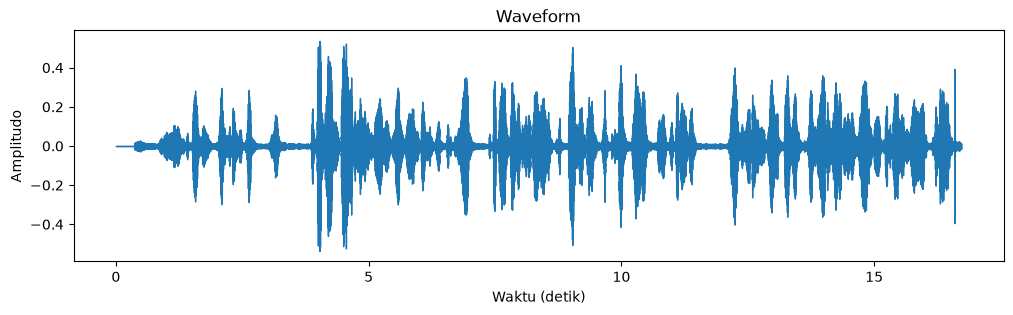

In [15]:
plt.figure(figsize=(12, 3))   # membuat gambar dengan ukuran 12x3 inci
librosa.display.waveshow(y, sr=sr)  #menampilan grafik waveform dari sinyal audio terhadap waktu
plt.title("Waveform") 
plt.xlabel("Waktu (detik)")
plt.ylabel("Amplitudo")
plt.show()

### Spektrum FFT

mengubah sinyal dari domain waktu ke domain frekuensi, sehingga frekuensi yang ada pada rekaman bisa dilihat.

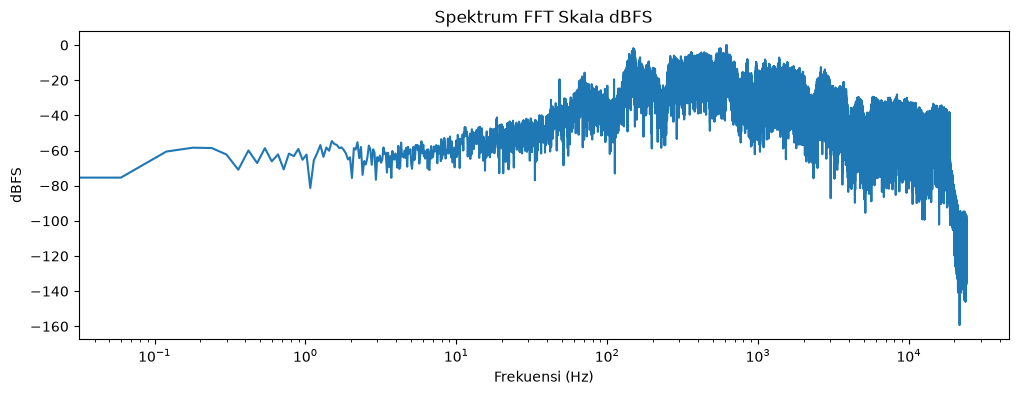

In [17]:
# FFT mengubah sinyal dari domain waktu ke domain frekuensi
Y_fft = np.fft.rfft(y)                    # hasil FFT (berupa angka kompleks)
freqs = np.fft.rfftfreq(len(y), 1/sr)  # frekunsi yang bersesuaian dengan hasil FFT hz
magnitude = np.abs(Y_fft)       #berdsarkan nilai kekuatab signal (magnitude)

# Mengubah magnitude ke skala dBFS
magnitude_dbfs = 20 * np.log10(magnitude / np.max(magnitude) + 1e-9)

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude_dbfs)
plt.title("Spektrum FFT Skala dBFS")
plt.xlabel("Frekuensi (Hz)")
plt.ylabel("dBFS")

# Menggunakan skala log agar frekuensi rendah lebih terlihat
plt.xscale('log')   
plt.show()

### Menemukan Frekuensi Dominan Noise

Mengambil bagian awal audio yang masih hening untuk mencari frekuensi noise yang paling dominan.

In [18]:
durasi_sampel_hening = 0.5 # durasi sampel hening dalam detik
n_sampel_hening = int(durasi_sampel_hening * sr) # mengubah durasi menjadi jumlah sampel (titik data) berdasarkan laju sampel
segmen_hening = y[:n_sampel_hening]   # mengambil bagian awal saja

fft_hening = np.abs(np.fft.rfft(segmen_hening)) #menghitung FFT dari segmen hening dan mengambil magnitudenya
freqs_hening = np.fft.rfftfreq(len(segmen_hening), 1/sr) #menentukan frekunsi gening 

idx_dominan = np.argmax(fft_hening)     
freq_dominan = freqs_hening[idx_dominan]  

print(f"Frekuensi paling dominan dari noise statis (bagian hening): {freq_dominan:.1f} Hz")

Frekuensi paling dominan dari noise statis (bagian hening): 70.0 Hz


### Spektrogram STFT
melihat perubahan frekuensi suara dari waktu ke waktu.

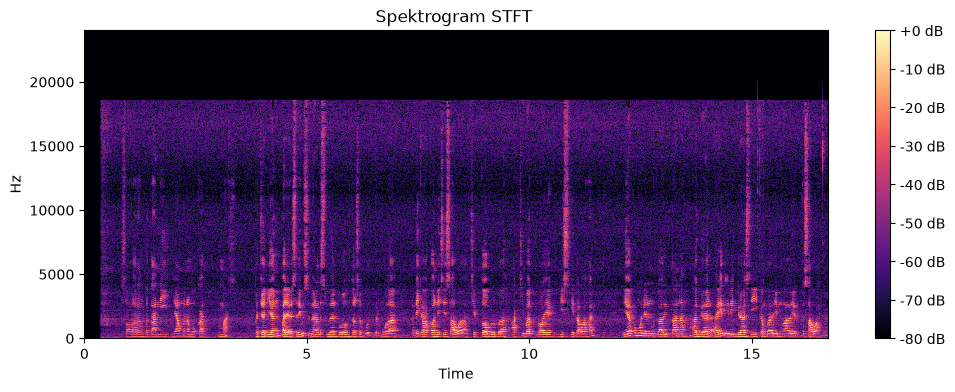

In [19]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)   # mengubah hasil STFT ke skala dBFS (Decibels Full Scale) 

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format="%+2.0f dB") # Menampilkan skala kekuatan sinyal
plt.title("Spektrogram STFT ")
plt.show()

### Mel Spektrogram
frekuensi suara dengan skala Mel yang disesuaikan dengan pendengaran manusia.

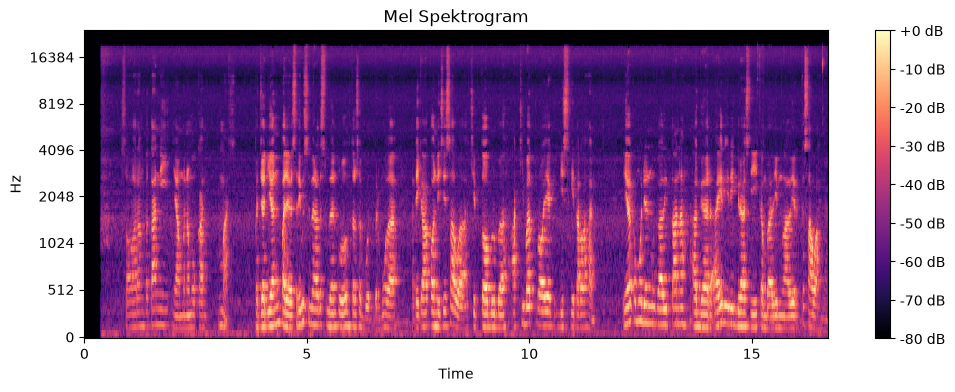

In [20]:
M = librosa.feature.melspectrogram(y=y, sr=sr) # Membuat Mel-Spektrogram dari audio
M_db = librosa.power_to_db(M, ref=np.max) # Mengubah hasil ke skala desibel

plt.figure(figsize=(12, 4)) 
librosa.display.specshow(M_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spektrogram")
plt.show()

## Resampling dan aliasing audio
 dimana menurunkan kualitas audio dengan dua cara berbeda lalu membadingkan hasilnya


In [26]:
# A. downsampling (naive decimation)
# Menurunkan sr audio ke 8.000 Hz dan mengamil sebagian sampel tanpa filtering 

target_sr = 8000 # Menentukan laju sampel target (misalnya 8000 Hz)

faktor_potong = sr // target_sr # Menentukan faktor pengurangan sampel

y_kasar = y[::faktor_potong] # Mengambil setiap sampel ke-n

print(f" A selesai Jumlah sampel: {len(y_kasar)}")

 A selesai Jumlah sampel: 133803


In [27]:
# B. resampling audio dengan filter
#Menurunkan sr menggunakan resampling dengan filter untuk mengurangi risiko aliasing.

y_bersih = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

print(f" B selesai Jumlah sampel setelah resampling halus: {len(y_bersih)}")

 B selesai Jumlah sampel setelah resampling halus: 133803


In [29]:
#menyimpan file audio resampling

wavfile.write("audio_downsampled_naive.wav", target_sr, (y_kasar * 32767).astype(np.int16))
wavfile.write("audio_downsampled_clean.wav", target_sr, (y_bersih * 32767).astype(np.int16))

print("file a dan b telah di simpan ")

file a dan b telah di simpan 


Spektogram dengan filtering dan tanaoa filtering 

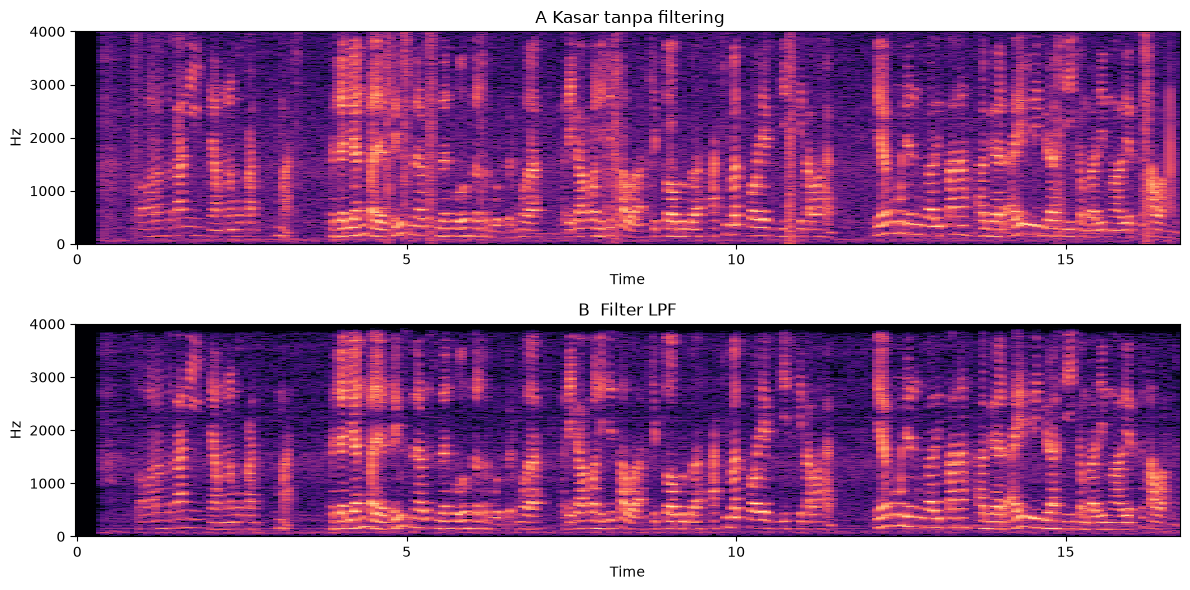

In [31]:
plt.figure(figsize=(12, 6)) 

plt.subplot(2, 1, 1)
D_kasar = librosa.stft(y_kasar)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(D_kasar), ref=np.max), sr=target_sr, x_axis='time', y_axis='hz')
plt.title(" A Kasar tanpa filtering")

plt.subplot(2, 1, 2)
D_bersih = librosa.stft(y_bersih)
librosa.display.specshow(librosa.amplitude_to_db(np.abs(D_bersih), ref=np.max), sr=target_sr, x_axis='time', y_axis='hz')
plt.title(" B  Filter LPF ")

plt.tight_layout()
plt.show()